In [1]:
building = 3
time = 24
price = 'Realistic'
noise = 0

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import math

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]

In [4]:
if noise == 0:
    nl_data['load_fcst'] = nl_data['load']
else:
    load_fcst_data = pd.read_csv('../data/load_fcsts/building_' + str(building) + '_' + str(noise) + '_noise_forecast.csv', index_col=0)
    nl_data['load_fcst'] = load_fcst_data['load'].values

In [5]:
battery_capacity = round(nl_data['load'].resample('Y').sum().max() * 1.1 / 1000,1)

C:\Users\joris\AppData\Local\Temp\ipykernel_25836\4246776486.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  battery_capacity = round(nl_data['load'].resample('Y').sum().max() * 1.1 / 1000,1)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [7]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
opt_future_features = ['hour_sin','hour_cos','load', 'load_fcst','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, 0, 0]
domain_max = [None, None, None, 1, 1, 1, 1, 1]

In [8]:
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [9]:
lowest_T = 23

In [10]:
dictionary_list_perfect = pvb_system.execute_optimization(time,lowest_T,'Perfect',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split, noise=noise)
dictionary_list_naive = pvb_system.execute_optimization(time,lowest_T,'Naive',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split, noise=noise)
dictionary_list_lstm = pvb_system.execute_optimization(time,lowest_T,'LSTM',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split, noise=noise)
dictionary_list_cvx = pvb_system.execute_optimization(time,lowest_T,'CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split, noise=noise)
dictionary_list_lstm_cvx = pvb_system.execute_optimization(time,lowest_T,'LSTM_CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split, noise=noise)

Setting up optimization for 0:00
Setting up optimization for 0:00
Setting up optimization for 0:00
Setting up optimization for 0:00
Setting up optimization for 0:00


In [11]:
perfect_cost = (dictionary_list_perfect[0]['offtake'] * dictionary_list_perfect[0]['imp']) - (dictionary_list_perfect[0]['injection'] * dictionary_list_perfect[0]['exp'])
naive_cost = (dictionary_list_naive[0]['offtake'] * dictionary_list_naive[0]['imp']) - (dictionary_list_naive[0]['injection'] * dictionary_list_naive[0]['exp'])
lstm_cost = (dictionary_list_perfect[0]['offtake'] * dictionary_list_lstm[0]['imp']) - (dictionary_list_lstm[0]['injection'] * dictionary_list_lstm[0]['exp'])
cvx_cost = (dictionary_list_cvx[0]['offtake'] * dictionary_list_cvx[0]['imp']) - (dictionary_list_cvx[0]['injection'] * dictionary_list_cvx[0]['exp'])
lstm_cvx_cost = (dictionary_list_lstm_cvx[0]['offtake'] * dictionary_list_lstm_cvx[0]['imp']) - (dictionary_list_lstm_cvx[0]['injection'] * dictionary_list_lstm_cvx[0]['exp'])

np.sum(perfect_cost), np.sum(naive_cost), np.sum(lstm_cost), np.sum(cvx_cost), np.sum(lstm_cvx_cost)

(138.8412770383216,
 187.6879711568324,
 190.05968615666052,
 176.8546719290639,
 175.0818540537102)

In [12]:
hours = range(0,1)

tot_cost_perfect = []
tot_cost_lstm = []
tot_cost_cvx_lstm = []
tot_cost_cvx = []

for hour in hours:
    perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
    naive_cost = (dictionary_list_naive[hour]['offtake'][:,0] * dictionary_list_naive[hour]['imp'][:,0]) - (dictionary_list_naive[hour]['injection'][:,0] * dictionary_list_naive[hour]['exp'][:,0])
    lstm_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
    cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])

    tot_cost_perfect.append(perfect_cost)
    tot_cost_lstm.append(lstm_cost)
    tot_cost_cvx_lstm.append(lstm_cvx_cost)
    tot_cost_cvx.append(cvx_cost)

np.sum(tot_cost_perfect), np.sum(tot_cost_lstm), np.sum(tot_cost_cvx), np.sum(tot_cost_cvx_lstm)

(2.8488420401756835, 2.5451349052978527, 3.765987140908851, 3.1540895066792842)

In [13]:
pilot_day = 100
model = dictionary_list_lstm_cvx
model_2 = dictionary_list_lstm
variable = 'pv'

final_schedule = np.empty(len(model))
final_schedule_2 = np.empty(len(model))

for i in range(len(model)):
    final_schedule[i] = model[i][variable][pilot_day][0]
    final_schedule_2[i] = model_2[i][variable][pilot_day][0]

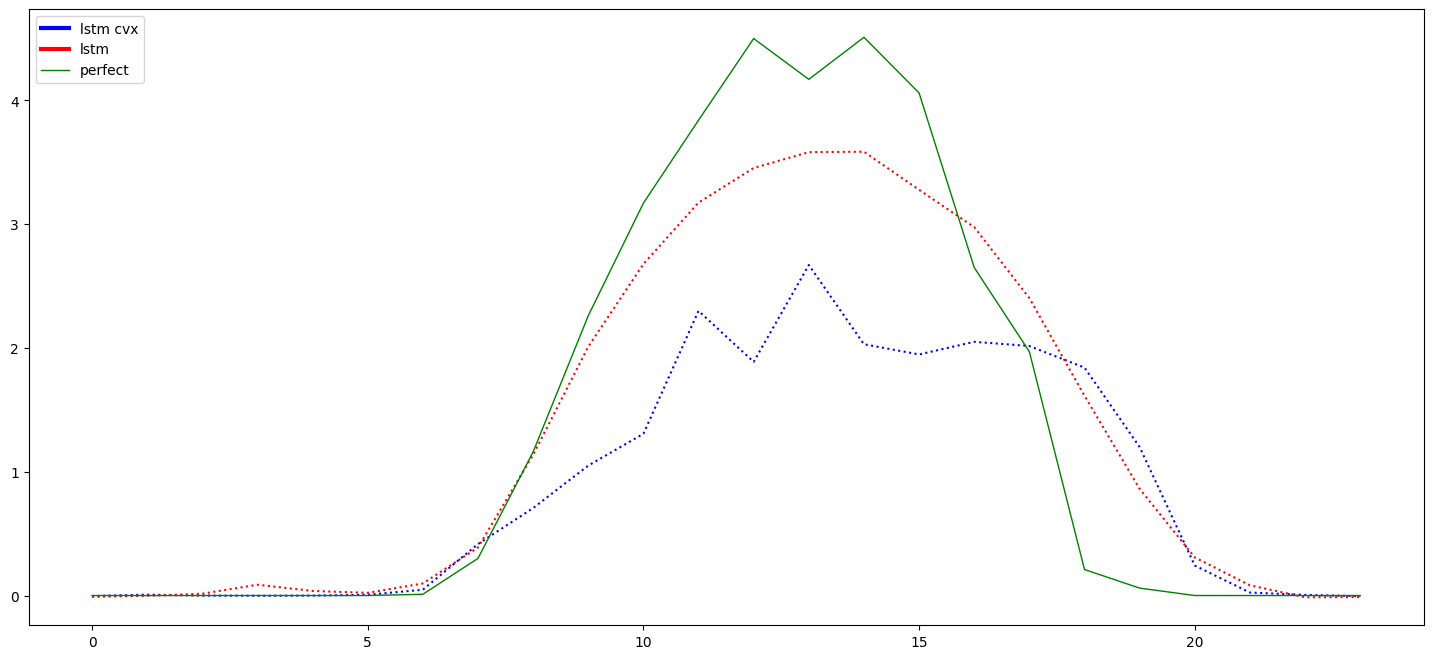

In [14]:
plt.figure(figsize=(18,8))

# Plot energy data on ax1
plt.plot(model[0][variable][pilot_day], linestyle=':', color='b')
for i in range(1, len(model)):
    plt.plot(np.pad(model[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), linestyle=':', color='b')

plt.plot(final_schedule, color='b', linewidth=3, label='lstm cvx')

plt.plot(model_2[0][variable][pilot_day], linestyle=':', color='r')
for i in range(1, len(model_2)):
    plt.plot(np.pad(model_2[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan), linestyle=':', color='r')

plt.plot(final_schedule_2, color='r', linewidth=3, label='lstm')

plt.plot(dictionary_list_perfect[0][variable][pilot_day], color='g', linewidth=1, label='perfect')

plt.legend(loc='upper left')

plt.show()

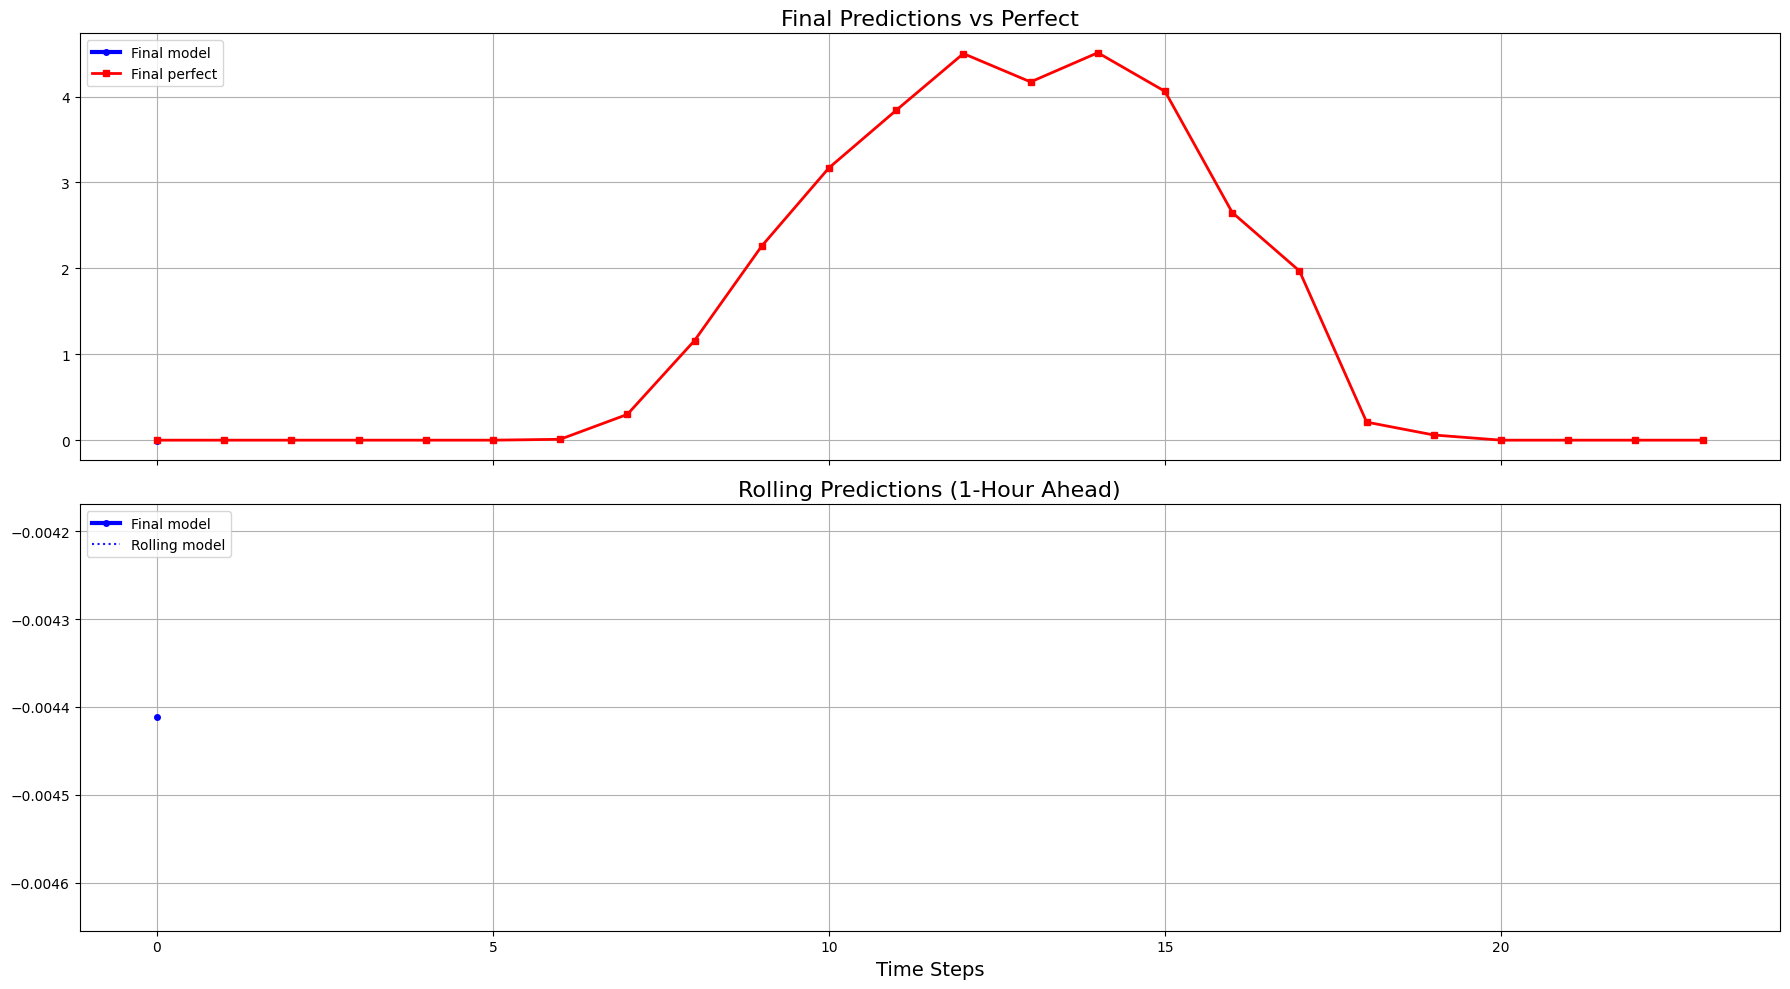

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Set up figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# --------------------------------
# TOP PLOT — Final Predictions
# --------------------------------

# Final model prediction
ax1.plot(final_schedule, color='b', linewidth=3, label='Final model', marker='o', markersize=4)

# Final perfect prediction
ax1.plot(dictionary_list_perfect[0][variable][pilot_day], color='r', linewidth=2, label='Final perfect', marker='s', markersize=4)

ax1.set_title('Final Predictions vs Perfect', fontsize=16)
ax1.legend(loc='upper left')
ax1.grid(True)

# --------------------------------
# BOTTOM PLOT — Rolling Predictions
# --------------------------------

# Rolling model predictions (faded blue)
for i in range(1, len(model)):
    ax2.plot(
        np.pad(model[i][variable][pilot_day], (i, 0), mode='constant', constant_values=np.nan),
        linestyle=':', color='b', alpha=0.8, linewidth=1
    )

# Final model prediction
ax2.plot(final_schedule, color='b', linewidth=3, label='Final model', marker='o', markersize=4)
# Add dummy lines for legend
ax2.plot([], [], linestyle=':', color='b', alpha=0.9, label='Rolling model')

ax2.set_title('Rolling Predictions (1-Hour Ahead)', fontsize=16)
ax2.legend(loc='upper left')
ax2.grid(True)

# --------------------------------
# Final layout tweaks
# --------------------------------

plt.xlabel('Time Steps', fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
dimport matplotlib.pyplot as plt
import numpy as np

# Assuming dictionary_list_perfect and dictionary_list_lstm_cvx contain dicts
# Each 'pv' is an array with decreasing length: [450, 449, ..., 427]

fig, axs = plt.subplots(4, 6, figsize=(18, 12))
axs = axs.flatten()

for i in range(24):
    # Get the 'pv' arrays for the current index i
    x = dictionary_list_lstm_cvx[i]['pv'] - dictionary_list_perfect[i]['pv']
    y = dictionary_list_lstm[i]['pv'] - dictionary_list_perfect[i]['pv']
    
    # Ensure that we're only plotting the common length
    min_len = min(len(x), len(y))
    x = x[:min_len]
    y = y[:min_len]

    # Scatter plot for the current feature pair
    axs[i].scatter(x, y, alpha=0.7)
    
    # Set axis labels
    axs[i].set_xlabel("cvx", fontsize=10)
    axs[i].set_ylabel("lstm", fontsize=10)
    
    # Set axis limits (making sure both axes have the same limits)
    max_val = max(np.max(x), np.max(y),4)
    min_val = min(np.min(x), np.min(y),-4)
    axs[i].set_xlim(min_val, max_val)
    axs[i].set_ylim(min_val, max_val)
    
    # Draw red lines through 0 (horizontal and vertical axes)
    axs[i].axhline(0, color='red', linewidth=1.5)
    axs[i].axvline(0, color='red', linewidth=1.5)
    
    # Title and ticks
    axs[i].set_title(f"Index {i}", fontsize=10)
    axs[i].tick_params(labelsize=8)

# Global layout adjustments
plt.tight_layout()
plt.suptitle("Scatter Plots: 'pv' from lstm_cvx vs perfect", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


SyntaxError: invalid syntax (3787259727.py, line 1)

In [ ]:
var = 'pv'

# Collect all difference arrays into a list of lists
all_differences = [
    dictionary_list_lstm_cvx[i][var][:, 0] - dictionary_list_lstm[i][var][:, 0]
    for i in range(24)
]

plt.figure(figsize=(14, 7))

# Boxplot
plt.boxplot(all_differences, positions=np.arange(1, 25), widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='black', marker='o', markersize=3, linestyle='none'))

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(ticks=range(1, 25))
plt.xlabel('Index (1–24)')
plt.ylabel('Difference')
plt.title(f'Boxplots of differences in "{var}" across 24 indices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
var = 'pv'

# Step 1: Convert list of 24 arrays (each length 450) into a NumPy array of shape (450, 24)
# Each row = a day, each column = an hour of the day (0–23)
difference_array = np.column_stack(all_differences)  # shape: (450, 24)

# Step 2: Create datetime index for each row/day
start = pd.Timestamp("2020-05-08")
dates = pd.date_range(start=start, periods=450, freq='D')  # one per row

# Step 3: Create DataFrame
df_diffs = pd.DataFrame(difference_array, index=dates, columns=[f'hour_{h}' for h in range(24)])

# Step 4: Plot one boxplot per month (showing hourly differences)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for month in range(1, 13):
    ax = axes[month - 1]
    
    # Filter for rows in the specific month
    monthly_data = df_diffs[df_diffs.index.month == month]

    # Get data as list of arrays, one per hour
    data_for_boxplot = [monthly_data[f'hour_{h}'].values for h in range(24)]

    ax.boxplot(data_for_boxplot, positions=np.arange(1, 25), widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightgray', color='black'),
               medianprops=dict(color='red'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               flierprops=dict(markerfacecolor='black', marker='o', markersize=3, linestyle='none'))

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(1, 25))
    ax.set_title(pd.Timestamp(2020, month, 1).strftime('%B'))
    ax.set_xlabel('Hour of Day')
    if month in [1, 5, 9]:  # left-most plots
        ax.set_ylabel('Difference')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f'Hourly Differences in "{var}" Across Months', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import imageio.v2 as imageio
import os

# Step 1: Create folder to save frames
os.makedirs("gif_frames", exist_ok=True)

# Step 2: Loop through each month, create and save a boxplot
frames = []
for month in range(1, 13):
    plt.figure(figsize=(15, 10))

    # Filter data for current month
    monthly_data = df_diffs[df_diffs.index.month == month]
    data_for_boxplot = [monthly_data[f'hour_{h}'].values for h in range(24)]

    # Create boxplot
    plt.boxplot(data_for_boxplot, positions=np.arange(1, 25), widths=0.5, patch_artist=True,
                boxprops=dict(facecolor='lightgray', color='black'),
                medianprops=dict(color='red'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(markerfacecolor='black', marker='o', markersize=3, linestyle='none'))

    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.xticks(range(1, 25), [str(h).zfill(2) for h in range(24)])
    plt.xlabel('Hour of Day')
    plt.ylabel('Difference')
    plt.ylim(-3,4)
    plt.title(f'Hourly Differences in "{var}" – {pd.Timestamp(2020, month, 1).strftime("%B")}')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    # Save frame as PNG
    filename = f"gif_frames/lstm_vs_cvx_frame_{month:02d}.png"
    plt.savefig(filename)
    plt.close()

    frames.append(imageio.imread(filename))  # Read frame for GIF

# Create the GIF and loop it twice
frames_for_gif = frames + frames[::-1]  # Append reversed frames for the transition from December to January
imageio.mimsave('lstm_vs_cvx_hourly_differences_by_month_loop_twice.gif', frames_for_gif, duration=200, loop=2)

In [ ]:
np.sum(tot_cost_perfect), np.sum(tot_cost_lstm), np.sum(tot_cost_cvx), np.sum(tot_cost_cvx_lstm)

In [ ]:
hours = range(0,17)

tot_cost_perfect = []
tot_cost_lstm = []
tot_cost_cvx_lstm = []
tot_cost_cvx = []

for hour in hours:
    perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
    naive_cost = (dictionary_list_naive[hour]['offtake'][:,0] * dictionary_list_naive[hour]['imp'][:,0]) - (dictionary_list_naive[hour]['injection'][:,0] * dictionary_list_naive[hour]['exp'][:,0])
    lstm_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
    cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])
    
    tot_cost_perfect.append(perfect_cost)
    tot_cost_lstm.append(lstm_cost)
    tot_cost_cvx_lstm.append(lstm_cvx_cost)
    tot_cost_cvx.append(cvx_cost)
    
perfect_cost = (dictionary_list_perfect[hour+1]['offtake'] * dictionary_list_perfect[hour+1]['imp']) - (dictionary_list_perfect[hour+1]['injection'] * dictionary_list_perfect[hour+1]['exp'])
naive_cost = (dictionary_list_naive[hour+1]['offtake'] * dictionary_list_naive[hour+1]['imp']) - (dictionary_list_naive[hour+1]['injection'] * dictionary_list_naive[hour+1]['exp'])
lstm_cost = (dictionary_list_perfect[hour+1]['offtake'] * dictionary_list_lstm[hour+1]['imp']) - (dictionary_list_lstm[hour+1]['injection'] * dictionary_list_lstm[hour+1]['exp'])
cvx_cost = (dictionary_list_cvx[hour+1]['offtake'] * dictionary_list_cvx[hour+1]['imp']) - (dictionary_list_cvx[hour+1]['injection'] * dictionary_list_cvx[hour+1]['exp'])
lstm_cvx_cost = (dictionary_list_lstm_cvx[hour+1]['offtake'] * dictionary_list_lstm_cvx[hour+1]['imp']) - (dictionary_list_lstm_cvx[hour+1]['injection'] * dictionary_list_lstm_cvx[hour+1]['exp'])

tot_cost_perfect.append(np.sum(perfect_cost,axis=1))
tot_cost_lstm.append(np.sum(lstm_cost,axis=1))
tot_cost_cvx_lstm.append(np.sum(lstm_cvx_cost,axis=1))
tot_cost_cvx.append(np.sum(cvx_cost,axis=1))

np.sum(tot_cost_perfect), np.sum(tot_cost_lstm), np.sum(tot_cost_cvx), np.sum(tot_cost_cvx_lstm)

In [ ]:
perfect = []
lstm = []
cvx = []
lstm_cvx = []

for i in range(1,24):
    
    hours = range(0,i)
    
    tot_cost_perfect = []
    tot_cost_lstm = []
    tot_cost_cvx_lstm = []
    tot_cost_cvx = []
    
    for hour in hours:
        perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
        lstm_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
        cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
        lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])
        
        tot_cost_perfect.append(perfect_cost)
        tot_cost_lstm.append(lstm_cost)
        tot_cost_cvx_lstm.append(lstm_cvx_cost)
        tot_cost_cvx.append(cvx_cost)
        
    perfect_cost = (dictionary_list_perfect[hour+1]['offtake'] * dictionary_list_perfect[hour+1]['imp']) - (dictionary_list_perfect[hour+1]['injection'] * dictionary_list_perfect[hour+1]['exp'])
    lstm_cost = (dictionary_list_perfect[hour+1]['offtake'] * dictionary_list_lstm[hour+1]['imp']) - (dictionary_list_lstm[hour+1]['injection'] * dictionary_list_lstm[hour+1]['exp'])
    cvx_cost = (dictionary_list_cvx[hour+1]['offtake'] * dictionary_list_cvx[hour+1]['imp']) - (dictionary_list_cvx[hour+1]['injection'] * dictionary_list_cvx[hour+1]['exp'])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour+1]['offtake'] * dictionary_list_lstm_cvx[hour+1]['imp']) - (dictionary_list_lstm_cvx[hour+1]['injection'] * dictionary_list_lstm_cvx[hour+1]['exp'])
    
    tot_cost_perfect.append(np.sum(perfect_cost,axis=1))
    tot_cost_lstm.append(np.sum(lstm_cost,axis=1))
    tot_cost_cvx_lstm.append(np.sum(lstm_cvx_cost,axis=1))
    tot_cost_cvx.append(np.sum(cvx_cost,axis=1))
    
    perfect.append(np.sum(tot_cost_perfect))
    lstm.append(np.sum(tot_cost_lstm))
    lstm_cvx.append(np.sum(tot_cost_cvx_lstm))
    cvx.append(np.sum(tot_cost_cvx))

In [ ]:
plt.figure(figsize=(10,8))

plt.plot(perfect, label='Perfect')
plt.plot(lstm, label='LSTM')
plt.plot(cvx, label='CVX')
plt.plot(lstm_cvx, label='LSTM-CVX')

plt.legend()
plt.show()

In [ ]:
min(perfect), min(lstm), min(cvx), min(lstm_cvx)

In [ ]:
perfect_np = np.stack(tot_cost_perfect,axis=1)
lstm_np = np.stack(tot_cost_lstm, axis=1)
lstm_cvx_np = np.stack(tot_cost_cvx_lstm, axis=1)

In [ ]:
# Flatten each to 1D (since each row has 24 hours)
flat1 = perfect_np.flatten()
flat2 = lstm_np.flatten()
flat3 = lstm_cvx_np.flatten()

# Create the datetime index
start = pd.Timestamp("2020-05-08 00:00:00")
end = pd.Timestamp("2021-07-31 23:00:00")
index = pd.date_range(start=start, end=end, freq="H")  # hourly frequency

# Confirm that the lengths match
assert len(flat1) == len(index) == 450 * 24

# Create the DataFrame
df = pd.DataFrame({
    'Perfect': flat1,
    'LSTM': flat2,
    'LSTM-CVX': flat3,
}, index=index)

In [ ]:
# Choose the series you want to analyze
series = (df['LSTM-CVX'] - df['Perfect']) - (df['LSTM'] - df['Perfect'])

# Group values by hour of the day
hourly_groups = [series[series.index.hour == h].values for h in range(24)]

plt.figure(figsize=(14, 7))

# Create the boxplot
plt.boxplot(hourly_groups, positions=np.arange(1, 25), widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='black', marker='o', markersize=3, linestyle='none'))

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(ticks=range(1, 25), labels=[str(h).zfill(2) + ":00" for h in range(24)])
plt.xlabel('Hour of Day')
plt.ylabel('Value')
plt.title('Boxplots of values across each hour of the day')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# Choose the column you want to analyze
series = df['LSTM-CVX'].resample('D').sum() - df['Perfect'].resample('D').sum()

# Group values by month (1 = Jan, ..., 12 = Dec)
monthly_groups = [series[series.index.month == m].values for m in range(1, 13)]

plt.figure(figsize=(14, 7))

# Create the boxplot
plt.boxplot(monthly_groups, positions=np.arange(1, 13), widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='lightgray', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='black', marker='o', markersize=3, linestyle='none'))

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])
plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Boxplots of values across each month')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()